In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Euler
def euler(f, x, y, h):
    return y + h*f(x, y)

# Midpoint
def midpoint(f, x, y, h):
    k1 = h*f(x, y)
    return y + h*f(x + h/2, y + k1/2)

# RK4
def rk4(f, x, y, h):
    k1 = f(x, y)
    k2 = f(x + h/2, y + h*k1/2)
    k3 = f(x + h/2, y + h*k2/2)
    k4 = f(x + h, y + h*k3)

    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# Function for calling different methods
def caller(f, xs, y0, N, h, method):
    y = y0
    ys = np.zeros((N, len(y0)))

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(f, x, y, h)
    
    return ys

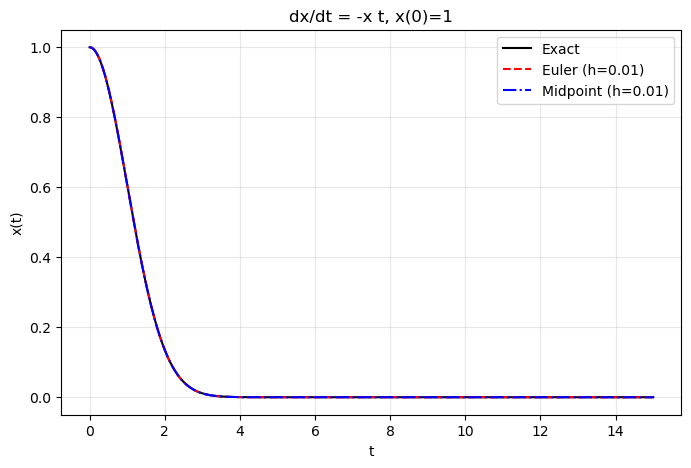

In [3]:
# Part (a): Solve dx/dt = -x t with Euler and Midpoint, h = 0.01, t in [0, 15]

def f(t, x):
    return -x * t

h = 0.01
t0, tf = 0.0, 15.0
N = int((tf - t0) / h) + 1
xs = np.linspace(t0, tf, N)

x0 = np.array([1.0])

euler_sol = caller(f, xs, x0, N, h, euler).squeeze()
mid_sol = caller(f, xs, x0, N, h, midpoint).squeeze()

# Exact solution: x(t) = exp(-t^2 / 2)
exact = np.exp(-0.5 * xs**2)

plt.figure(figsize=(8, 5))
plt.plot(xs, exact, 'k-', label='Exact')
plt.plot(xs, euler_sol, 'r--', label='Euler (h=0.01)')
plt.plot(xs, mid_sol, 'b-.', label='Midpoint (h=0.01)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('dx/dt = -x t, x(0)=1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [4]:
# Part (b): Error at final point for h = 10^n, n from -4 to -2 in steps of 0.2

def exact_solution(t):
    return np.exp(-0.5 * t**2)

n_values = np.arange(-4.0, -2.0 + 1e-9, 0.2)
h_values = 10**n_values

t0, tf = 0.0, 15.0
x0 = np.array([1.0])

errors_euler = []
errors_mid = []

for h in h_values:
    N = int((tf - t0) / h) + 1
    xs = np.linspace(t0, tf, N)

    euler_sol = caller(f, xs, x0, N, h, euler).squeeze()
    mid_sol = caller(f, xs, x0, N, h, midpoint).squeeze()

    exact_tf = exact_solution(tf)

    errors_euler.append(abs(euler_sol[-1] - exact_tf))
    errors_mid.append(abs(mid_sol[-1] - exact_tf))

errors_euler = np.array(errors_euler)
errors_mid = np.array(errors_mid)

# Tabulate results
results_b = pd.DataFrame({
    'n': n_values,
    'h': h_values,
    'Euler_error': errors_euler,
    'Midpoint_error': errors_mid
})

results_b


,n,h,Euler_error,Midpoint_error
0,-4.0,0.000100,7.490051e-51,2.887951e-54
1,-3.8,0.000158,1.159595e-50,1.064496e-52
2,-3.6,0.000251,1.805482e-50,3.799226e-53
3,-3.4,0.000398,2.745826e-50,1.687191e-52
4,-3.2,0.000631,4.093637e-50,3.770720e-52
5,-3.0,0.001000,5.878214e-50,1.337355e-51
6,-2.8,0.001585,8.146986e-50,1.335109e-51
7,-2.6,0.002512,1.047666e-49,3.492257e-51
8,-2.4,0.003981,1.240610e-49,8.419620e-51
9,-2.2,0.006310,1.350703e-49,1.515982e-50


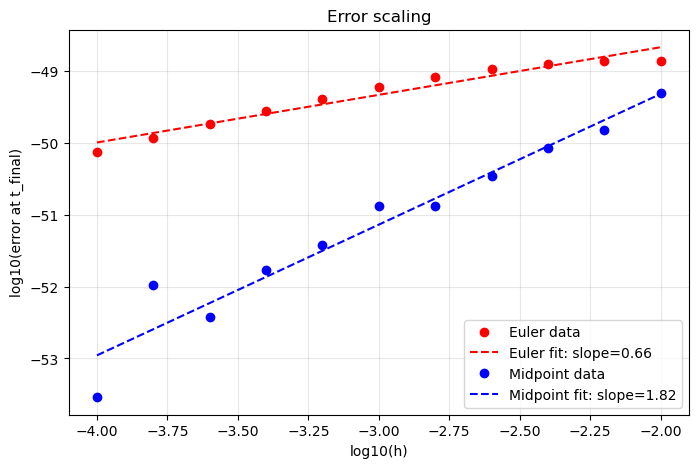

In [5]:
# Part (c): Plot log10(h) vs log10(error) and fit straight line

def linear_fit(x, m, c):
    return m * x + c

logh = np.log10(h_values)
logerr_euler = np.log10(errors_euler)
logerr_mid = np.log10(errors_mid)

popt_euler, _ = curve_fit(linear_fit, logh, logerr_euler)
popt_mid, _ = curve_fit(linear_fit, logh, logerr_mid)

m_euler, c_euler = popt_euler
m_mid, c_mid = popt_mid

plt.figure(figsize=(8, 5))
plt.plot(logh, logerr_euler, 'ro', label='Euler data')
plt.plot(logh, linear_fit(logh, *popt_euler), 'r--', label=f'Euler fit: slope={m_euler:.2f}')
plt.plot(logh, logerr_mid, 'bo', label='Midpoint data')
plt.plot(logh, linear_fit(logh, *popt_mid), 'b--', label=f'Midpoint fit: slope={m_mid:.2f}')

plt.xlabel('log10(h)')
plt.ylabel('log10(error at t_final)')
plt.title('Error scaling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


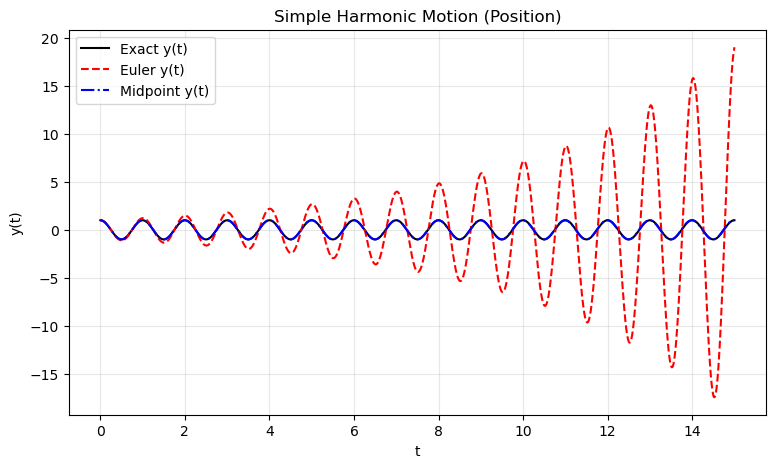

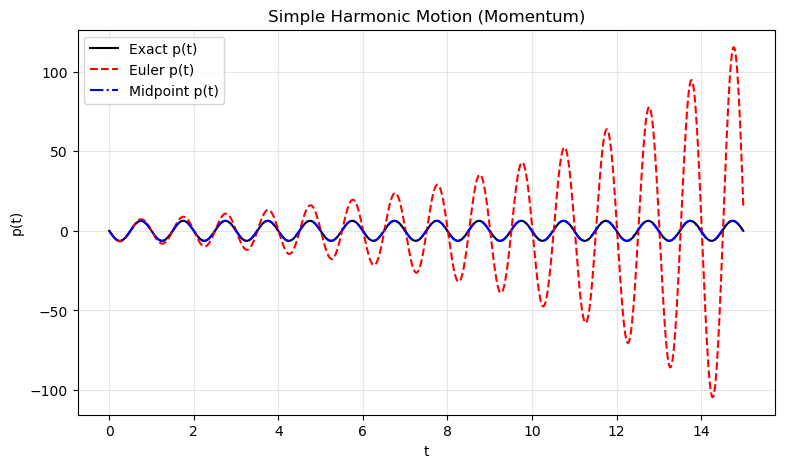

In [6]:
# Question 2(a): Coupled SHO system using Euler and Midpoint, h = 0.01, t in [0, 15]

def f_sho(t, y):
    # y = [position, momentum]
    pos, mom = y
    dpos = mom
    dmom = -4 * (np.pi**2) * pos
    return np.array([dpos, dmom])

h = 0.01
t0, tf = 0.0, 15.0
N = int((tf - t0) / h) + 1
xs = np.linspace(t0, tf, N)

y0 = np.array([1.0, 0.0])

# Euler and Midpoint solutions
sho_euler = caller(f_sho, xs, y0, N, h, euler)
sho_mid = caller(f_sho, xs, y0, N, h, midpoint)

# Exact solution: y(t) = cos(2? t), p(t) = dy/dt = -2? sin(2? t)
exact_y = np.cos(2 * np.pi * xs)
exact_p = -2 * np.pi * np.sin(2 * np.pi * xs)

plt.figure(figsize=(9, 5))
plt.plot(xs, exact_y, 'k-', label='Exact y(t)')
plt.plot(xs, sho_euler[:, 0], 'r--', label='Euler y(t)')
plt.plot(xs, sho_mid[:, 0], 'b-.', label='Midpoint y(t)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Simple Harmonic Motion (Position)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(xs, exact_p, 'k-', label='Exact p(t)')
plt.plot(xs, sho_euler[:, 1], 'r--', label='Euler p(t)')
plt.plot(xs, sho_mid[:, 1], 'b-.', label='Midpoint p(t)')
plt.xlabel('t')
plt.ylabel('p(t)')
plt.title('Simple Harmonic Motion (Momentum)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
# Question 2(b): Error at final point for h = 10^n, n from -4 to -2 in steps of 0.2

# Integrate with a fixed step h, but take a final partial step to land exactly on tf

def integrate_to_tf(f, t0, tf, y0, h, method):
    t = t0
    y = y0.copy()
    while t + h < tf:
        y = method(f, t, y, h)
        t += h
    # Final partial step if needed
    h_last = tf - t
    if h_last > 0:
        y = method(f, t, y, h_last)
    return y

n_values_q2 = np.arange(-4.0, -2.0 + 1e-9, 0.2)
h_values_q2 = 10**n_values_q2

t0, tf = 0.0, 15.0
y0 = np.array([1.0, 0.0])

errors_euler_q2 = []
errors_mid_q2 = []

for h in h_values_q2:
    y_euler_tf = integrate_to_tf(f_sho, t0, tf, y0, h, euler)
    y_mid_tf = integrate_to_tf(f_sho, t0, tf, y0, h, midpoint)

    exact_tf = exact_sho_y(tf)

    errors_euler_q2.append(abs(y_euler_tf[0] - exact_tf))
    errors_mid_q2.append(abs(y_mid_tf[0] - exact_tf))

errors_euler_q2 = np.array(errors_euler_q2)
errors_mid_q2 = np.array(errors_mid_q2)

results_q2b = pd.DataFrame({
    'n': n_values_q2,
    'h': h_values_q2,
    'Euler_error': errors_euler_q2,
    'Midpoint_error': errors_mid_q2
})

results_q2b


,n,h,Euler_error,Midpoint_error
0,-4.0,0.000100,0.030052,2.903028e-09
1,-3.8,0.000158,0.048045,1.151240e-08
2,-3.6,0.000251,0.077209,4.554937e-08
3,-3.4,0.000398,0.125102,1.795518e-07
4,-3.2,0.000631,0.205405,7.035576e-07
5,-3.0,0.001000,0.344580,2.730003e-06
6,-2.8,0.001585,0.598760,1.042037e-05
7,-2.6,0.002512,1.103467,3.865938e-05
8,-2.4,0.003981,2.248334,1.361008e-04
9,-2.2,0.006310,5.458069,4.296267e-04


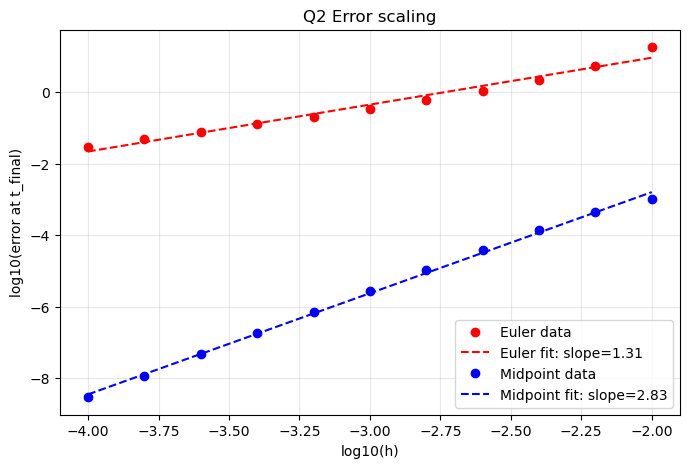

In [10]:
# Question 2(c): Plot log10(h) vs log10(error) and fit straight line

def linear_fit(x, m, c):
    return m * x + c

logh_q2 = np.log10(h_values_q2)
logerr_euler_q2 = np.log10(errors_euler_q2)
logerr_mid_q2 = np.log10(errors_mid_q2)

popt_euler_q2, _ = curve_fit(linear_fit, logh_q2, logerr_euler_q2)
popt_mid_q2, _ = curve_fit(linear_fit, logh_q2, logerr_mid_q2)

m_euler_q2, c_euler_q2 = popt_euler_q2
m_mid_q2, c_mid_q2 = popt_mid_q2

plt.figure(figsize=(8, 5))
plt.plot(logh_q2, logerr_euler_q2, 'ro', label='Euler data')
plt.plot(logh_q2, linear_fit(logh_q2, *popt_euler_q2), 'r--', label=f'Euler fit: slope={m_euler_q2:.2f}')
plt.plot(logh_q2, logerr_mid_q2, 'bo', label='Midpoint data')
plt.plot(logh_q2, linear_fit(logh_q2, *popt_mid_q2), 'b--', label=f'Midpoint fit: slope={m_mid_q2:.2f}')

plt.xlabel('log10(h)')
plt.ylabel('log10(error at t_final)')
plt.title('Q2 Error scaling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
